# btc commission fees analysis     

### import wrappers

In [1]:
import data
import data_eth as deth
import econometrics as ec

### fetch dataset

In [4]:
df = data.build_master_dataset()
df.shape

(5619, 26)

In [5]:
# Levels — shows scale, skew, and the heavy tails that justify logging
ec.summary_stats(df, cols=['fees_btc', 'price_usd', 'mempool_bytes',
                           'n_transactions', 'hash_rate', 'difficulty'])

,N,mean,median,std,min,max,skew,kurtosis
fees_btc,5619,5.343868e+01,2.292718e+01,9.458254e+01,0.017654,1.495946e+03,4.962668,36.699876
price_usd,5619,2.162644e+04,6.682680e+03,3.069889e+04,0.300000,1.247767e+05,1.543466,1.368039
mempool_bytes,3628,3.563670e+07,6.728946e+06,5.441201e+07,331706.630208,3.761115e+08,2.373752,7.151477
n_transactions,5619,2.421919e+05,2.528330e+05,1.661336e+05,569.000000,9.270100e+05,0.541605,0.185487
hash_rate,5619,1.895805e+08,4.101145e+07,2.965842e+08,0.115112,1.305500e+09,1.738731,1.901830
difficulty,5619,2.623113e+13,5.814662e+12,4.099775e+13,14484.162361,1.559730e+14,1.723064,1.792231


In [6]:
# Log-returns — what you actually regress; should be ~zero-mean, fat-tailed
ec.summary_stats(df, cols=['d_log_fees_btc', 'd_log_price_usd',
                           'd_log_mempool_bytes', 'd_log_n_transactions'])

,N,mean,median,std,min,max,skew,kurtosis
d_log_fees_btc,5618,0.000589,-0.010084,0.339467,-3.778235,4.333994,0.380272,20.700266
d_log_price_usd,5618,0.002217,0.000921,0.042329,-0.496601,0.410915,0.023289,14.580631
d_log_mempool_bytes,3627,-0.000915,0.004014,0.646689,-3.607578,3.565240,0.093885,3.056885
d_log_n_transactions,5618,0.001234,-0.005388,0.147836,-1.023785,1.135649,0.166210,3.315198


### main regression and stationarity

In [7]:
ec.stationarity_table(df, cols=['log_fees_btc', 'log_price_usd', 'log_mempool_bytes',
                                 'd_log_fees_btc', 'd_log_price_usd', 'd_log_mempool_bytes'])

,adf_stat,adf_p,kpss_stat,kpss_p,verdict
variable,,,,,
log_fees_btc,-3.920210,1.891048e-03,1.480238,0.010000,inconclusive
log_price_usd,-2.307794,1.694667e-01,11.280195,0.010000,non-stationary
log_mempool_bytes,-2.489134,1.181405e-01,0.551017,0.030176,non-stationary
d_log_fees_btc,-17.049178,8.093059e-30,0.340318,0.100000,stationary
d_log_price_usd,-10.768838,2.413350e-19,0.564568,0.027124,inconclusive
d_log_mempool_bytes,-15.764968,1.179457e-28,0.053659,0.100000,stationary


In [8]:
sub = df.dropna(subset=['d_log_mempool_bytes', 'd_log_n_transactions', 'd_log_hash_rate'])

# Does adding hashrate change anything? (use hash_rate OR difficulty, not both)
m_full   = ec.run_ols('d_log_fees_btc ~ d_log_price_usd + d_log_mempool_bytes + d_log_n_transactions', sub)
m_hash   = ec.run_ols('d_log_fees_btc ~ d_log_price_usd + d_log_mempool_bytes + d_log_n_transactions + d_log_hash_rate', sub)
print(ec.compare_models([m_full, m_hash], names=['Full', 'Full + hashrate']))


                        Full   Full + hashrate
----------------------------------------------
Intercept            -0.0013   -0.0011        
                     (0.0024)  (0.0024)       
d_log_price_usd      0.2818**  0.2886**       
                     (0.1223)  (0.1219)       
d_log_mempool_bytes  0.1764*** 0.1687***      
                     (0.0084)  (0.0112)       
d_log_n_transactions 0.5798*** 0.6262***      
                     (0.0546)  (0.0761)       
d_log_hash_rate                -0.1059*       
                               (0.0641)       
R-squared            0.3249    0.3264         
R-squared Adj.       0.3244    0.3257         
Adj. R²              0.324     0.326          
N                    3627      3627           
R²                   0.325     0.326          
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [9]:
# Common sample so all three models use the same rows (fair R² comparison)
sub = df.dropna(subset=['d_log_mempool_bytes', 'd_log_n_transactions'])

m1 = ec.run_ols('d_log_fees_btc ~ d_log_price_usd', sub)
m2 = ec.run_ols('d_log_fees_btc ~ d_log_price_usd + d_log_mempool_bytes', sub)
m3 = ec.run_ols('d_log_fees_btc ~ d_log_price_usd + d_log_mempool_bytes + d_log_n_transactions', sub)
print(ec.compare_models([m1, m2, m3], names=['Price only', '+Mempool', 'Full']))

# Keep the full-history price-only result separately, for reference
m_full = ec.run_ols('d_log_fees_btc ~ d_log_price_usd', df)
print(f"\nFull-sample price-only: coef={m_full.params['d_log_price_usd']:.4f}, "
      f"p={m_full.pvalues['d_log_price_usd']:.4f}, N={int(m_full.nobs)}")


                     Price only  +Mempool    Full  
---------------------------------------------------
Intercept            -0.0015    -0.0012   -0.0013  
                     (0.0027)   (0.0025)  (0.0024) 
d_log_price_usd      0.4327***  0.3648*** 0.2818** 
                     (0.1487)   (0.1230)  (0.1223) 
d_log_mempool_bytes             0.1972*** 0.1764***
                                (0.0080)  (0.0084) 
d_log_n_transactions                      0.5798***
                                          (0.0546) 
R-squared            0.0034     0.2283    0.3249   
R-squared Adj.       0.0031     0.2278    0.3244   
Adj. R²              0.003      0.228     0.324    
N                    3627       3627      3627     
R²                   0.003      0.228     0.325    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01

Full-sample price-only: coef=0.1927, p=0.2260, N=5618


In [10]:
eras = data.split_by_halving(df)
for name, era_df in eras.items():
    n_mempool = era_df['d_log_mempool_bytes'].notna().sum()
    print(f'\n--- {name}  (rows={len(era_df)}, mempool obs={n_mempool}) ---')

    # Include mempool only if the era has enough of it; else price-only
    formula = 'd_log_fees_btc ~ d_log_price_usd'
    if n_mempool > 50:
        formula += ' + d_log_mempool_bytes'

    try:
        m = ec.run_ols(formula, era_df)
        print(f'formula: {formula}')
        print(m.summary())
    except Exception as e:
        print(f'  skipped ({type(e).__name__}): {e}')


--- era_1_pre_2012  (rows=697, mempool obs=0) ---
formula: d_log_fees_btc ~ d_log_price_usd
                            OLS Regression Results                            
Dep. Variable:         d_log_fees_btc   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.3196
Date:                Fri, 22 May 2026   Prob (F-statistic):              0.572
Time:                        22:20:11   Log-Likelihood:                -672.15
No. Observations:                 696   AIC:                             1348.
Df Residuals:                     694   BIC:                             1357.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------

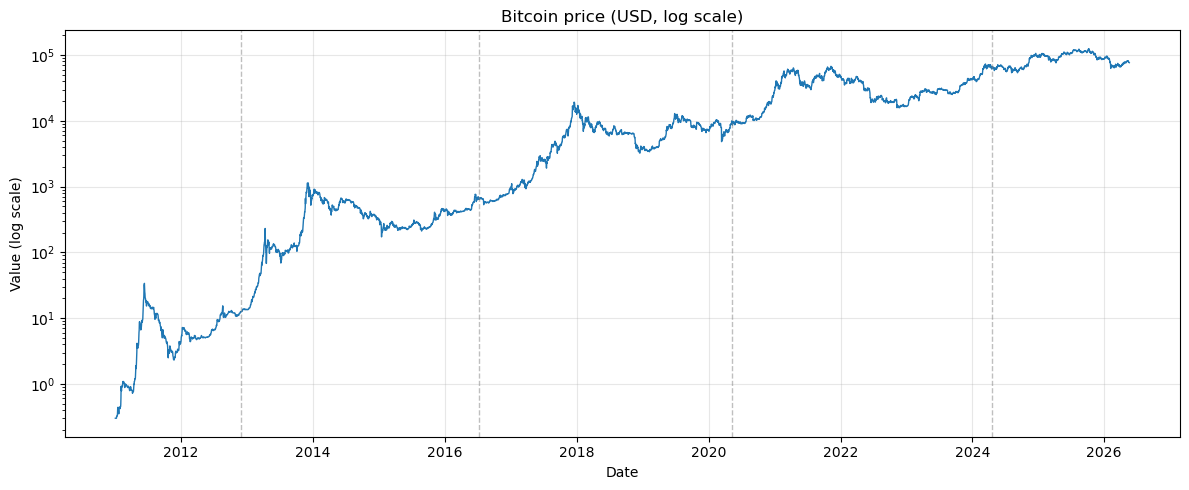

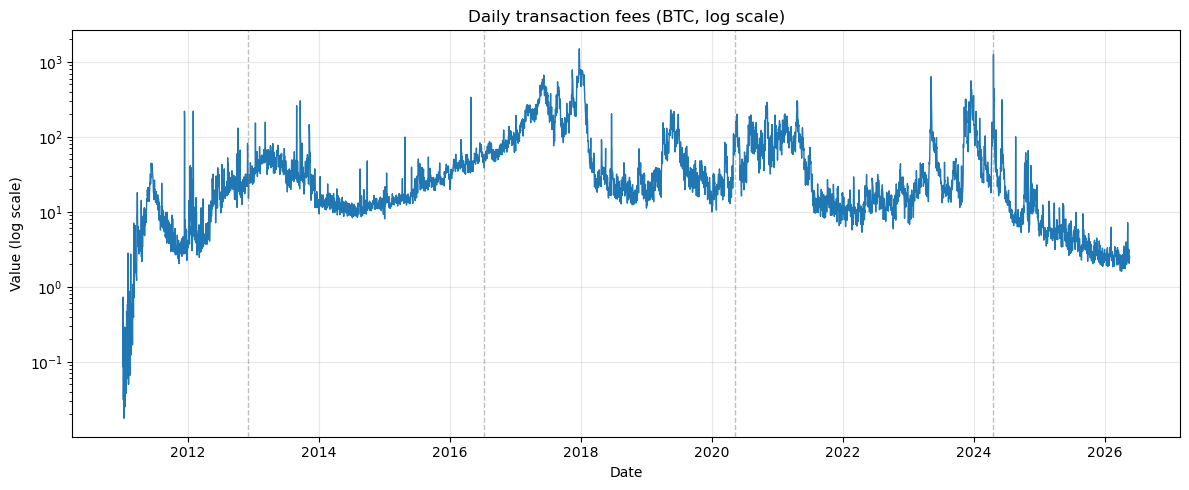

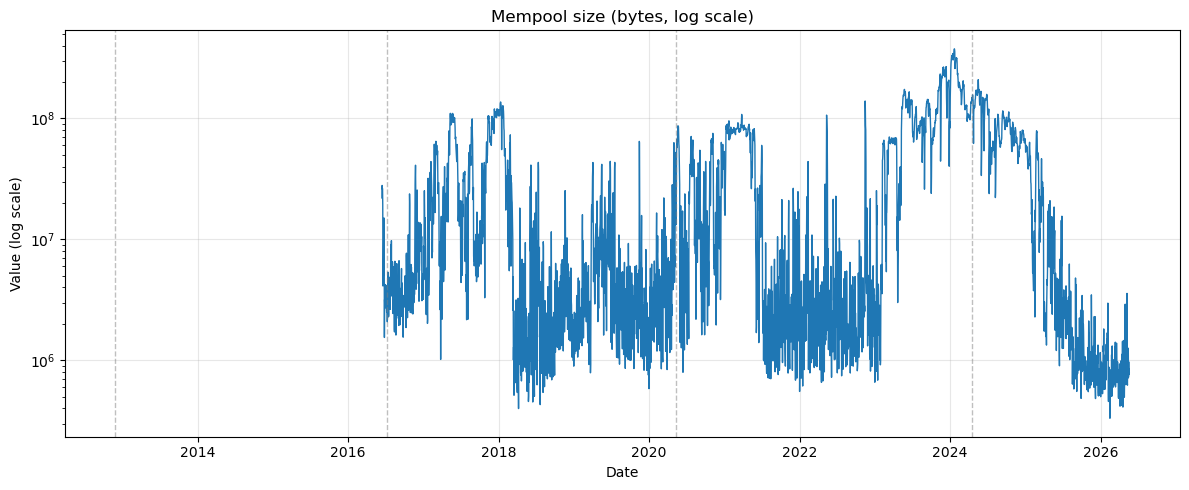

In [11]:
# 1. Bitcoin price, log scale, with halvings — the "here's the asset" chart
ec.plot_series(df, ['price_usd'], log=True, halvings=True,
               title='Bitcoin price (USD, log scale)')

# 2. Fees in BTC, log scale, with halvings — your dependent variable
ec.plot_series(df, ['fees_btc'], log=True, halvings=True,
               title='Daily transaction fees (BTC, log scale)')

# 3. Mempool size — the variable that turns out to matter most
ec.plot_series(df, ['mempool_bytes'], log=True, halvings=True,
               title='Mempool size (bytes, log scale)');

Correlation: 0.999379
Mean abs % diff: 2.335%
Overlapping days: 4,264


<Axes: title={'center': 'blockchain.com vs Yahoo Finance'}, xlabel='date'>

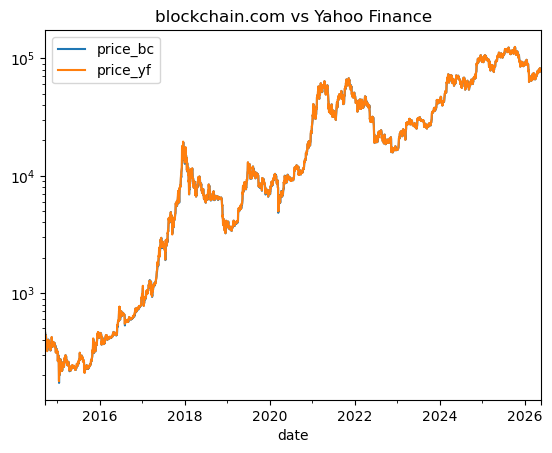

In [12]:
df_yf = data.fetch_yfinance_btc(start='2011-01-01')
cmp = data.compare_price_sources(df, df_yf)
print(f"Correlation: {cmp['correlation']:.6f}")
print(f"Mean abs % diff: {cmp['mean_abs_pct_diff']:.3f}%")
print(f"Overlapping days: {cmp['n_obs']:,}")
cmp['merged'].plot(logy=True, title='blockchain.com vs Yahoo Finance')

In [13]:
ec.chow_test_multiple(df, ['2016-07-09','2020-05-11','2024-04-19'],
                      formula='d_log_fees_btc ~ d_log_price_usd + d_log_mempool_bytes')


,f_statistic,p_value,df_num,df_denom,n_before,n_after,break
breakpoint,,,,,,,
2016-07-09,0.610050,6.084411e-01,3,3621,24,3603,False
2020-05-11,4.104543,6.439690e-03,3,3621,1426,2201,True
2024-04-19,10.798066,4.625148e-07,3,3621,2865,762,True


In [14]:
ec.chow_test_multiple(df, data.HALVING_DATES,
                      formula='d_log_fees_btc ~ d_log_price_usd')

,f_statistic,p_value,df_num,df_denom,n_before,n_after,break
breakpoint,,,,,,,
2012-11-28,3.649236,0.026073,2,5614,696,4922,True
2016-07-09,2.546006,0.078485,2,5614,2015,3603,False
2020-05-11,4.282558,0.013852,2,5614,3417,2201,True
2024-04-19,0.124909,0.882580,2,5614,4856,762,False


In [17]:
### Export tables for report
import os
os.makedirs('tables', exist_ok=True)

# Main results table (stargazer)
from stargazer.stargazer import Stargazer
star = Stargazer([m1, m2, m3])
star.custom_columns(['Price only', '+Mempool', 'Full'], [1, 1, 1])
with open('tables/main_results.tex', 'w') as f:
    f.write(star.render_latex())

# Descriptives + Chow as DataFrames
ec.summary_stats(df, cols=['fees_btc', 'price_usd', 'mempool_bytes',
                           'n_transactions', 'hash_rate', 'difficulty']
                 ).round(4).to_latex('tables/summary_stats.tex')
chow = ec.chow_test_multiple(df, data.HALVING_DATES,
                             formula='d_log_fees_btc ~ d_log_price_usd')
chow.round(4).to_latex('tables/chow.tex')

# ETH Extension

In [2]:
eth = deth.build_master_dataset()
print(eth.shape)
print(eth.index.min().date(), '→', eth.index.max().date())
ec.summary_stats(eth, cols=['fees_eth', 'price_usd', 'n_transactions'])

(3796, 10)
2016-01-01 → 2026-05-23


,N,mean,median,std,min,max,skew,kurtosis
fees_eth,3796,2538.379527,7.206819e+02,4117.647763,15.650895,8.174749e+04,4.389487,45.863378
price_usd,3796,1423.419217,1.229899e+03,1316.406002,0.920370,4.831105e+03,0.577560,-0.899758
n_transactions,3796,918059.218915,1.042999e+06,518301.804273,8233.000000,3.627491e+06,0.279795,1.117144


In [3]:
eth_yf = deth.fetch_yfinance_eth(start='2016-01-01')
cmp_eth = deth.compare_price_sources(eth, eth_yf)
print(f"Correlation: {cmp_eth['correlation']:.6f}")
print(f"Mean abs % diff: {cmp_eth['mean_abs_pct_diff']:.3f}%")
print(f"Overlapping days: {cmp_eth['n_obs']:,}")

Correlation: 0.999979
Mean abs % diff: 0.320%
Overlapping days: 3,118


In [4]:
ec.stationarity_table(eth, cols=['log_fees_eth', 'log_price_usd',
                                  'd_log_fees_eth', 'd_log_price_usd'])

,adf_stat,adf_p,kpss_stat,kpss_p,verdict
variable,,,,,
log_fees_eth,-2.099756,2.446129e-01,3.550380,0.010000,non-stationary
log_price_usd,-3.238427,1.786539e-02,7.186862,0.010000,inconclusive
d_log_fees_eth,-14.705270,2.904035e-27,0.357366,0.095532,stationary
d_log_price_usd,-11.208626,2.153232e-20,0.676948,0.015641,inconclusive


In [5]:
m1 = ec.run_ols('d_log_fees_eth ~ d_log_price_usd', eth)
m2 = ec.run_ols('d_log_fees_eth ~ d_log_price_usd + d_log_n_transactions', eth)
print(ec.compare_models([m1, m2], names=['Price only', '+ Tx count']))


                     Price only + Tx count
------------------------------------------
Intercept            0.0013     -0.0009   
                     (0.0032)   (0.0030)  
d_log_price_usd      -0.3804**  -0.4525***
                     (0.1843)   (0.1682)  
d_log_n_transactions            1.5324*** 
                                (0.0986)  
R-squared            0.0029     0.1570    
R-squared Adj.       0.0026     0.1565    
Adj. R²              0.003      0.157     
N                    3795       3795      
R²                   0.003      0.157     
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [6]:
eras = deth.split_by_events(eth)
for name, era_df in eras.items():
    print(f'\n--- {name}  (rows={len(era_df)}) ---')
    print(ec.run_ols('d_log_fees_eth ~ d_log_price_usd + d_log_n_transactions',
                     era_df).summary())


--- era_1_pre_eip1559  (rows=2043) ---
                            OLS Regression Results                            
Dep. Variable:         d_log_fees_eth   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     79.87
Date:                Mon, 25 May 2026   Prob (F-statistic):           4.01e-34
Time:                        01:58:14   Log-Likelihood:                -453.61
No. Observations:                2042   AIC:                             913.2
Df Residuals:                    2039   BIC:                             930.1
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [7]:
ec.chow_test_multiple(eth, deth.ETH_EVENTS,
                      formula='d_log_fees_eth ~ d_log_price_usd + d_log_n_transactions')

,f_statistic,p_value,df_num,df_denom,n_before,n_after,break
breakpoint,,,,,,,
2021-08-05,0.667962,0.571656,3,3789,2042,1753,False
2022-09-15,0.607393,0.610163,3,3789,2448,1347,False


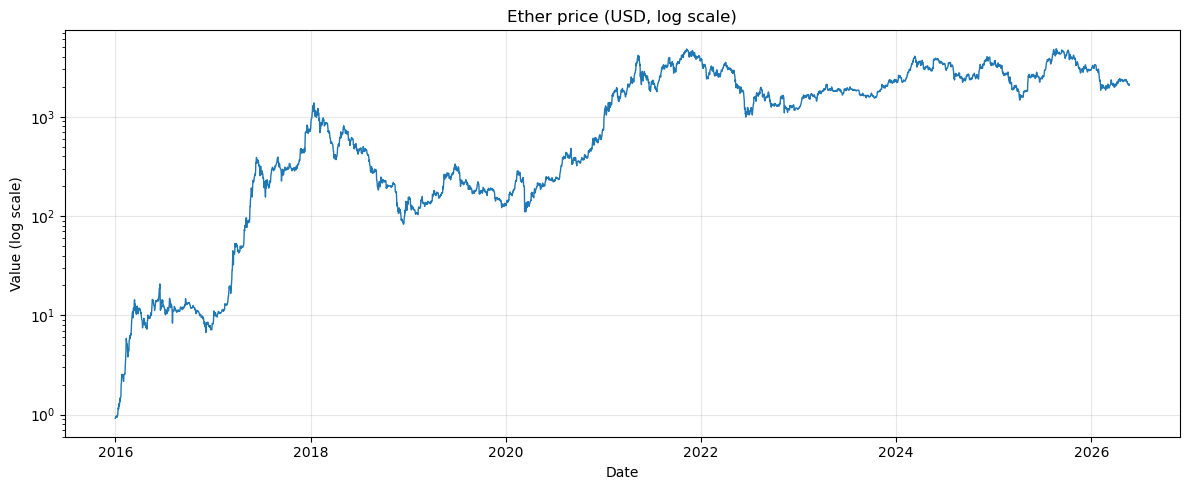

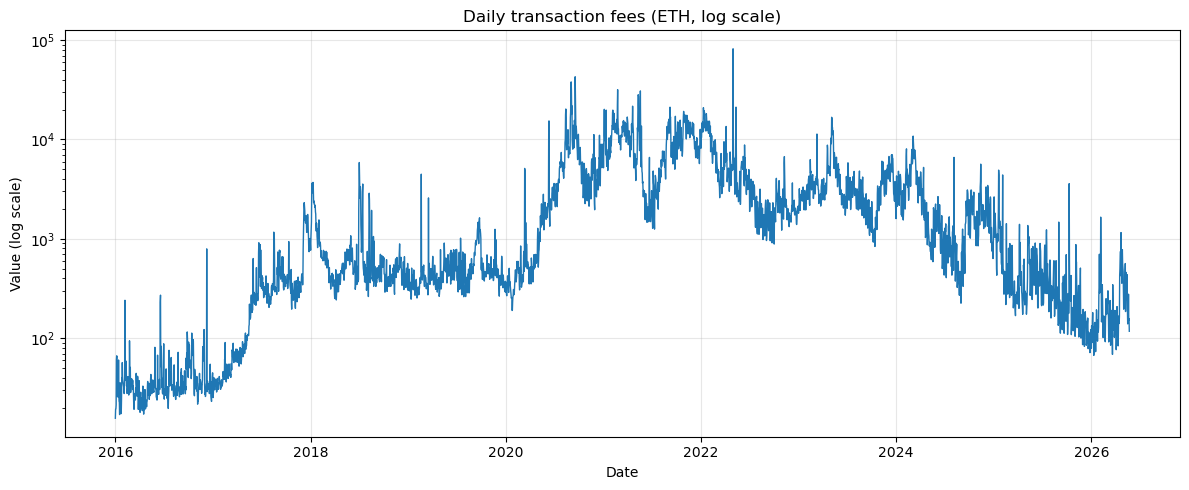

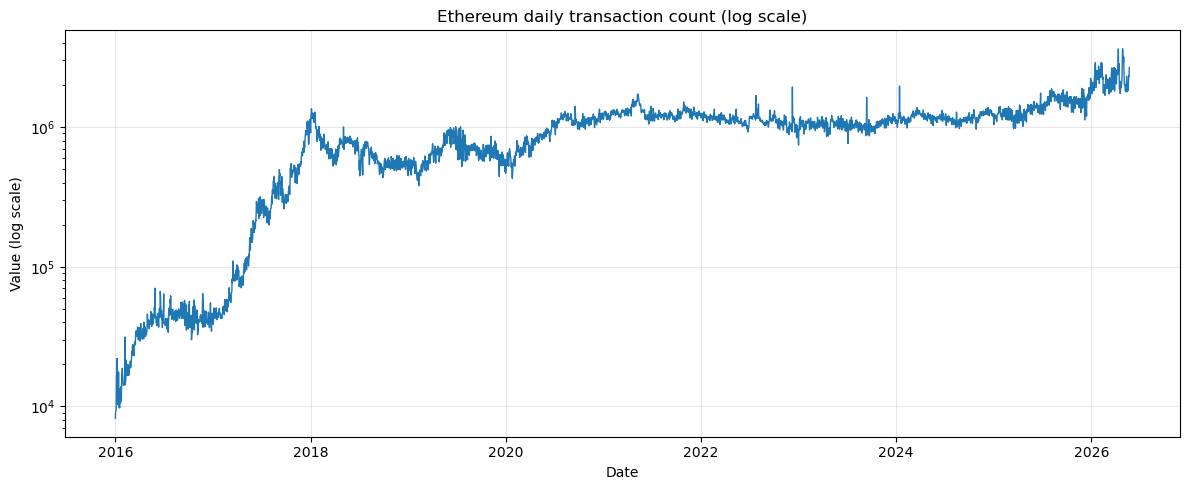

In [8]:
# 1. Ether price, log scale
ec.plot_series(eth, ['price_usd'], log=True,
               title='Ether price (USD, log scale)')

# 2. Fees in ETH, log scale — your dependent variable
ec.plot_series(eth, ['fees_eth'], log=True,
               title='Daily transaction fees (ETH, log scale)')

# 3. Transaction count — the demand proxy that carries the congestion role
ec.plot_series(eth, ['n_transactions'], log=True,
               title='Ethereum daily transaction count (log scale)');